In [36]:
import os
import sys
sys.path.append('..')
from jepa import QJEPA
from tqdm import tqdm
import json
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from qiskit_ibm_runtime.models import BackendProperties


In [37]:

"""
Here I intend to explore the relationships of noise sources of calibration data across time.
Intend to see how the noise profile shifts, and the severety of different errors change and shift
"""

# Constructs a df of all historical profiles 
def load_profiles():
    profiles = []
    files = [f for f in os.listdir("../calibrations") if f.endswith(".json") and "hist" in f]
    
    for filename in tqdm(files):
        filepath = os.path.join("../calibrations", filename)
        with open(filepath) as f:
            data = json.load(f)
        
        props = BackendProperties.from_dict(data["properties"])
        csc = QJEPA.compute_csc_from_props(props)
        
        profiles.append({
            "filename": filename,
            "backend": data["backend"],
            "date": data["date"],
            "csc": csc
        })
    
    print(f"Profiles Loaded: {len(profiles)}")
    prof_df = pd.DataFrame(profiles)
    prof_df['date'] = pd.to_datetime(prof_df['date'], utc=True)
    prof_df = prof_df.sort_values('date')
    return prof_df

df = load_profiles()

100%|██████████| 1510/1510 [00:18<00:00, 80.04it/s]

Profiles Loaded: 1510


/var/folders/_l/cwwj4qj94jd5t4h_007t7hrm0000gn/T/ipykernel_88817/1948508530.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


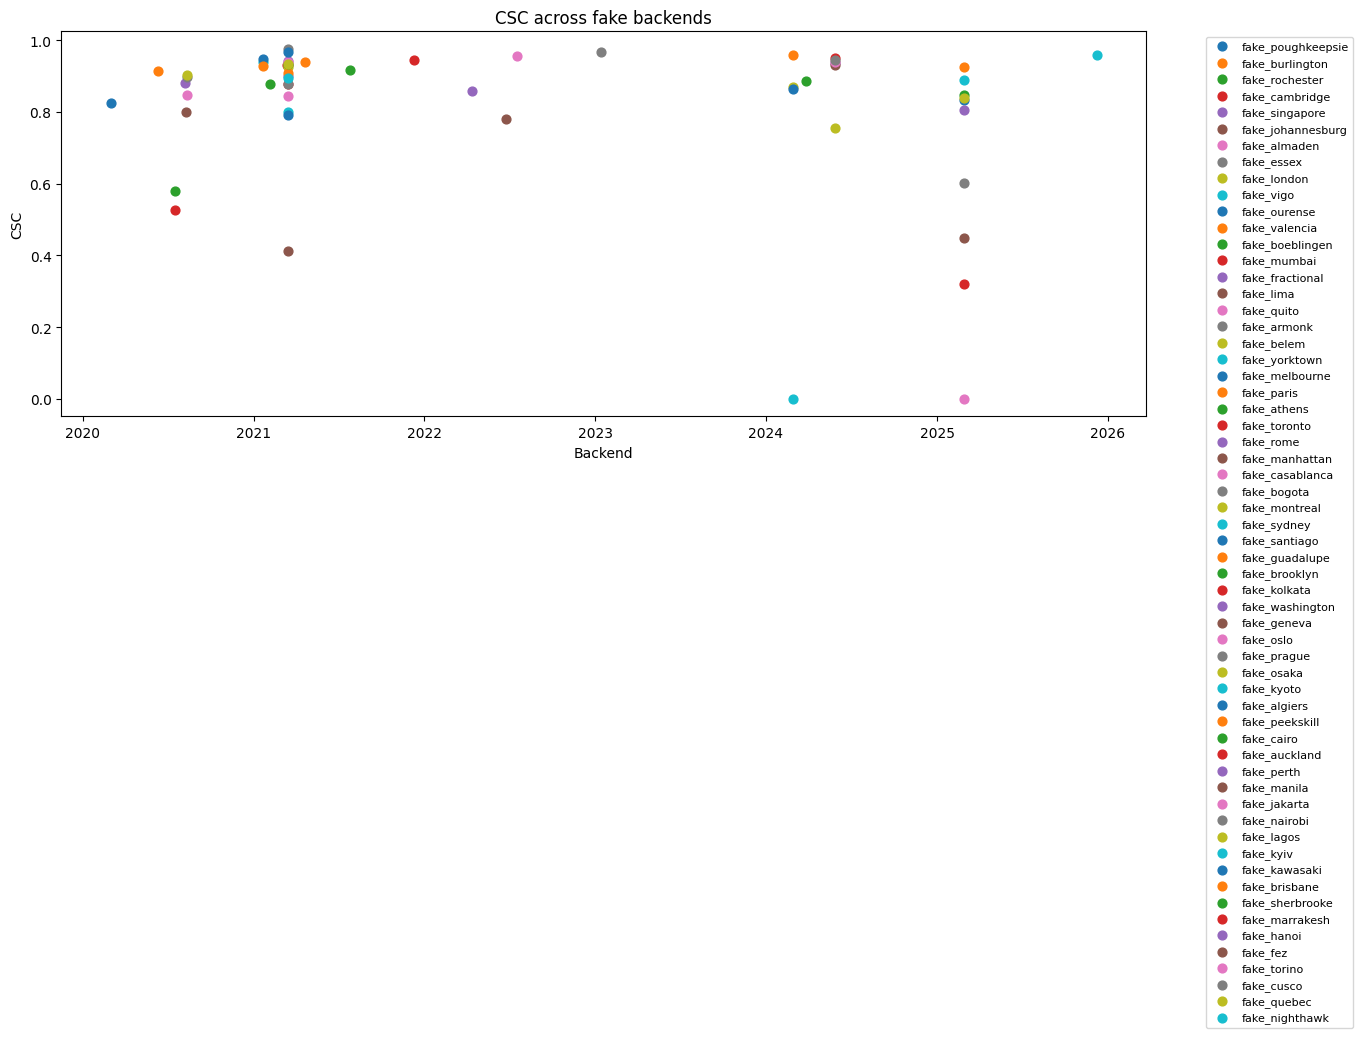

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

for backend in df['backend'].unique():
    data = df[df['backend'] == backend]
    ax.scatter(data['date'], data['csc'], label=backend, s=40)

ax.set_ylabel('CSC')
ax.set_xlabel('Backend')
ax.set_title('CSC across fake backends')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
low_csc = df[(df['csc'] < 0.6) & (df['csc'] > 0)]
low_csc

,filename,backend,date,csc
113,hist_ibm_fez_2024-11-07.json,ibm_fez,2024-11-07 04:57:28+00:00,0.006277
1106,hist_ibm_marrakesh_2024-11-15.json,ibm_marrakesh,2024-11-15 04:57:15+00:00,0.006168
90,hist_ibm_fez_2025-02-04.json,ibm_fez,2025-02-04 06:35:56+00:00,0.493301
274,hist_ibm_fez_2025-02-05.json,ibm_fez,2025-02-05 06:11:59+00:00,0.494003
1319,hist_ibm_fez_2025-02-06.json,ibm_fez,2025-02-06 04:54:17+00:00,0.315268
...,...,...,...,...
273,hist_ibm_kingston_2025-12-02.json,ibm_kingston,2025-12-02 00:27:04+00:00,0.213468
316,hist_ibm_marrakesh_2025-12-08.json,ibm_marrakesh,2025-12-07 23:37:49+00:00,0.292167
51,hist_ibm_marrakesh_2025-12-09.json,ibm_marrakesh,2025-12-09 00:27:55+00:00,0.567000
1278,hist_ibm_fez_2026-01-23.json,ibm_fez,2026-01-22 18:47:45+00:00,0.274662


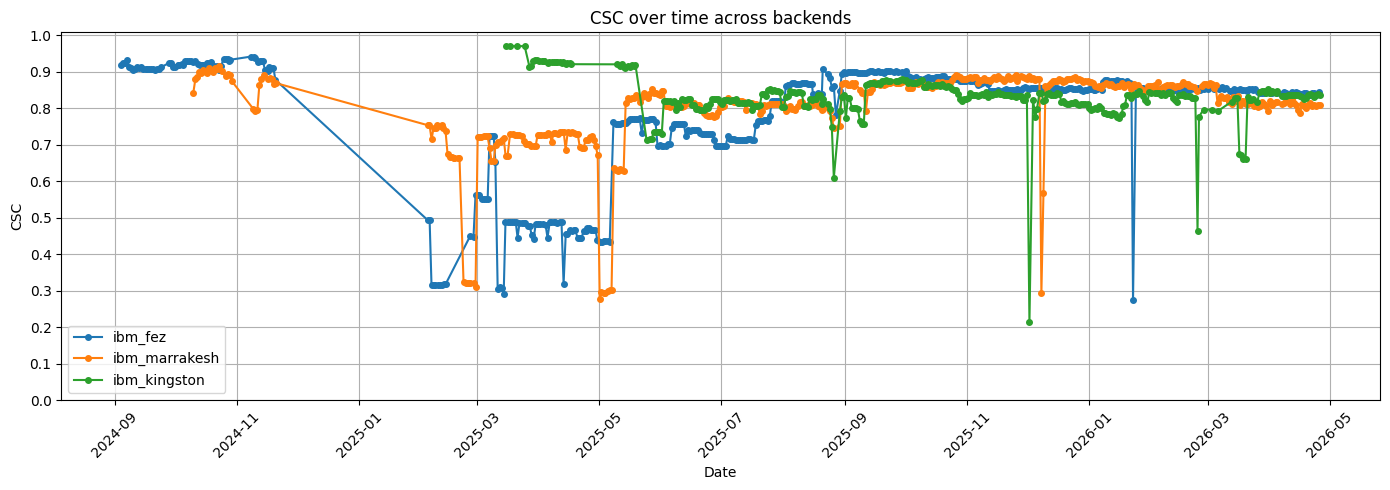

In [49]:
fez = df[df['backend'].str.contains('fez')]
marrakesh = df[df['backend'].str.contains('marrakesh')]
kingston = df[df['backend'].str.contains('kingston')]
fez = fez[fez["csc"] > 0.1]
marrakesh = marrakesh[marrakesh["csc"] > 0.1]
kingston = kingston[kingston["csc"] > 0.1]



fig, ax = plt.subplots(figsize=(14, 5))

for data, label in zip([fez, marrakesh, kingston], ['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']):
    ax.plot(data['date'], data['csc'], marker='o', linewidth=1.5, markersize=4, label=label)

ax.set_ylabel('CSC')
ax.set_xlabel('Date')
ax.set_title('CSC over time across backends')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.yticks(ticks=np.linspace(0,1,11))
plt.grid()
plt.show()